In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
np.random.seed(42)

# The Geometry of Optimization: From First Principles to Adaptive Flight

- Kushal Kharel

In the field of Artificial Intelligence, we view training not just as fitting a line but as a search for the global minimum within a loss manifold. For a linear model, the MSE (mean squared error) creates a convex quadratic surface.

In the previous gradient descent article, we dived deeper into mathematical foundation and inner workings of it. To build upon it and discuss other optimization method we will start with Vanilla Gradient Descent and end with Adam Optimizer. We will show the comparison and differences between different types of optimizers.

We know that it is very hard to visualize more than 3 dimensions (dimensionality constraint). A model with two features $(x_1, x_2)$ and a bias $(b)$ has three parameters. Mapping these against the loss would require a 4D plot. So, as researchers we resolve this by centering the target variable. By transforming $y => y - \bar y$, we mathematically force the optimal intercept to zero, allowing us to dedicate our 3D axes to the two primary weights and the resulting cost.

In [ ]:
# Generate data

n_samples = 5000

x1 = np.random.normal(0,1,n_samples) # feature 1
x2 = np.random.normal(0,5,n_samples) # feature 2

beta1 = 3.0 # coefficient 1
beta2 = -0.7 # coefficient 2

noise = np.random.normal(0,3,n_samples)

In [ ]:
# build a regression model

y = beta1*x1 + beta2*x2 + noise # Linear Regression Model

In [ ]:
X = np.column_stack([x1, x2])
y = y

In [ ]:
# Standardize features
X_std = (X - np.mean(X, axis=0))/np.std(X, axis=0)

# Standardize the Targets
# y_centered = y - np.mean(y) # this removes the bias
y_std = (y - y.mean()) / y.std()  # while centering is enough to make bias zero,
# we are standardizing y for better 3d viz and for gradient stability

# Storing the values for later to "un-scale" results
X_mu = np.mean(X, axis=0)
X_sigma = np.std(X, axis=0)

y_mu = y.mean()
y_sigma = y.std()

In [ ]:
# Analytical solution (Normal Equation), this is our Ground Truth target for the Gradient Descent

A = X_std.T @ X_std
b_vector = X_std.T @ y_std
A_inverse = np.linalg.inv(A)

x = A_inverse @ b_vector
# x = np.linalg.lstsq(X_std, y_std, rcond=None)[0]
# x = np.linalg.solve(A, b_vector)

print("Analytical solution (Normal Equation), this is our Ground Truth target for the Gradient Descent...")
print(f"Weights: {x[0]}, {x[1]}")
print(f"Optimal Bias: 0 (because we standardized y)")
print(f" \nThe equation is: {x[0]:.4f}*Feature1 + {x[1]:.4f}*Feature2 + {y_mu:.4f}")

Analytical solution (Normal Equation), this is our Ground Truth target for the Gradient Descent...
Weights: 0.5394942849061218, -0.6431669466966133
Optimal Bias: 0 (because we standardized y)
 
The equation is: 0.5395*Feature1 + -0.6432*Feature2 + 0.0830


In [ ]:
# Converting standardized weights back to real units
# real_w1 = x[0] * y_sigma/X_sigma[0]
# real_w2 = x[1] * y_sigma/X_sigma[1]

X_mu = np.mean(X, axis=0)
real_w = x * (y_sigma / X_sigma)
real_b = y_mu - np.sum(real_w * X_mu)

print(f"Real Equation: y = {real_w[0]:.2f}*Feature1 + {real_w[1]:.2f}*Feature2 + {real_b:.2f}")

Real Equation: y = 2.99*Feature1 + -0.70*Feature2 + 0.03


Note the equation above. When we standardized the features X, we shifted thier center to zero. We also centered the target which shifted its center to zero. In this centered universe, the best-fit line must pass through $(0,0,0)$. There is no bias $(b = 0)$.

However, for example, if this was a house prices dataset then a house price of zero is not a real-world prediction. To get back to the actual price, we have to undo the centering of y. Adding $y_{mean}$ is essentially shifting the entire regression plane back up from the origin to the average price level of the neighborhood.


Let's leave the explanation of our choices behind and continue on. Let us review vanilla gradient descent. Unlike the normal equation, which jumps straight to the answer, Gradient Descent "walk" down the manifold.

At its heart, training a neural network is an exercise of error correction. We have a loss function, $J(\theta)$, which measures the gap between what the network predicts and the actual truth. We want this gap to be as small as possible and this is where optimization techniques plays a vital role.

We define gradient descent as an iterative algorithm to minimize a cost function $J(\theta)$.

- The goal is to find the optimal model parameters (coefficients) that minimize the error.
- The step is to move in the opposite direction of the gradient $\nabla J(\theta)$ (which points toward the steepest ascent).
- The update rule is as follows:

$$
\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)
$$

where $\alpha$ is the learning rate, the critical scalar determining our step size.

In [ ]:
# batch gradient descent in action

def batch_gradient_descent(X, y, learning_rate=0.001, epochs=100, conv_threshold=1e-6):
  """
  Batch Gradient Descent for Linear Regression
  Model: y = Xw + b

  Returns:
    - final_weights
    - final_bias
    - history (parameter path)
    - loss_history
    - converged_epoch
  """

  m, n = X.shape

  # Initialize parameters
  weights = np.zeros(n)
  bias = 0.0

  # Store full optimization path including initial point
  history = [(weights.copy(), float(bias))]
  loss_history = []

  # store initial state
  predictions = X @ weights + bias
  error = predictions - y
  initial_mse = np.mean(error ** 2)
  loss_history.append(initial_mse)

  converged = False
  converged_epoch = epochs

  y_flat = y.reshape(-1)

  for epoch in range(epochs):

    # Forward pass
    predictions = X @ weights + bias
    error = predictions - y_flat

    # Gradients
    dw = (2 / m) * (X.T @ error)
    db = (2 / m) * np.sum(error)

    # Parameter update
    weights -= learning_rate * dw
    bias -= learning_rate * db

    # Store updated parameters
    history.append((weights.copy(), float(bias)))

    # Compute MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)

    # Convergence check
    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < conv_threshold:
      converged_epoch = epoch + 1
      print(f"Converged after {converged_epoch} epochs.")
      converged = True
      break

  if not converged:
    print(f"BGD finished {epochs} epochs without reaching convergence threshold.")
    print(f"Increase learning rate (current: {learning_rate}) if loss decreases slowly.")
    print(" Check feature scaling: BGD is sensitive to input scale.")

  return weights, bias, history, loss_history, converged_epoch

In [ ]:
# Run Algorithm (Ensure variable names match: X_std, y_std)
w_final, b_final, path, losses, converged_epoch = batch_gradient_descent(X_std, y_std, learning_rate=0.01, epochs=1000, conv_threshold=1e-6)

Converged after 255 epochs.


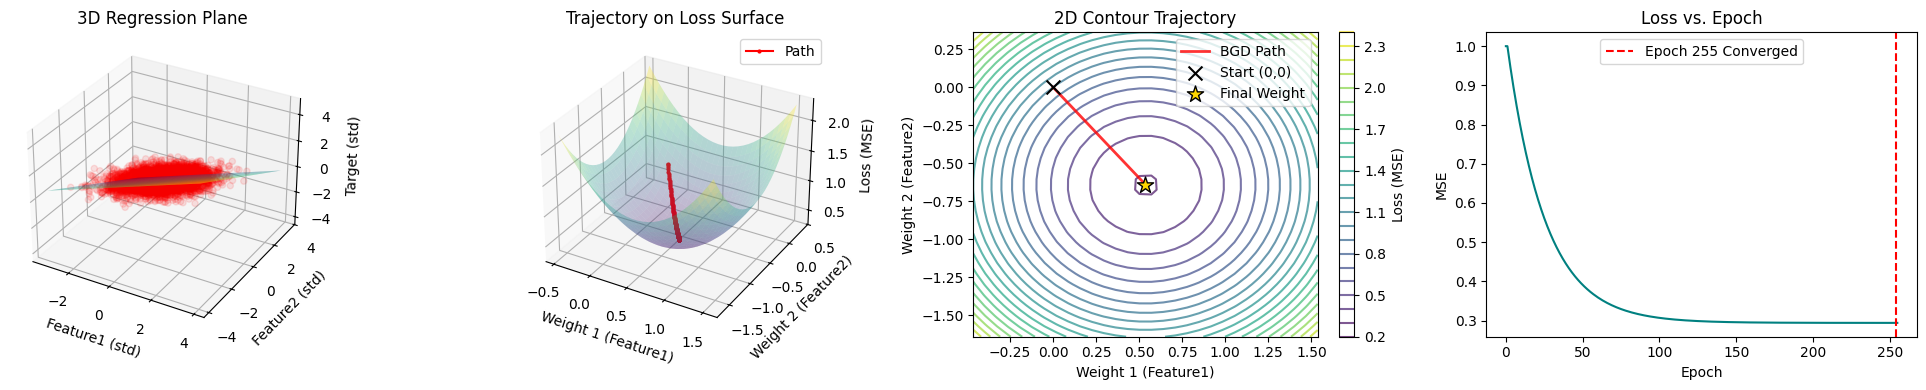

In [ ]:
x0_grid, x1_grid = np.meshgrid(
    np.linspace(X_std[:,0].min(), X_std[:,0].max(), 20),
    np.linspace(X_std[:,1].min(), X_std[:,1].max(), 20)
)

X_grid = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
y_grid = (X_grid @ w_final) + b_final
y_grid = y_grid.reshape(x0_grid.shape)

fig = plt.figure(figsize=(20, 4))

ax1 = fig.add_subplot(1, 4, 1, projection='3d')

ax1.scatter(X_std[:,0], X_std[:,1], y_std, color='red', alpha=0.1, label='Data points')
ax1.plot_surface(x0_grid, x1_grid, y_grid, alpha=0.5, cmap='viridis')
ax1.set_xlabel('Feature1 (std)')
ax1.set_ylabel('Feature2 (std)')
ax1.set_zlabel('Target (std)')
ax1.set_title('3D Regression Plane')

# trajectory in Parameter Space (3D)
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
w1_path = [p[0][0] for p in path]
w2_path = [p[0][1] for p in path]
w1_range = np.linspace(w_final[0] - 1.0, w_final[0] + 1.0, 30)
w2_range = np.linspace(w_final[1] - 1.0, w_final[1] + 1.0, 30)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z_loss = np.array([np.mean((w1 * X_std[:,0] + w2 * X_std[:,1] + b_final - y_std)**2) for w1, w2 in zip(np.ravel(W1), np.ravel(W2))]).reshape(W1.shape)
ax2.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.3, antialiased=True)
ax2.plot(w1_path, w2_path, losses, color='red', marker='o', markersize=2, label='Path')
ax2.set_title("Trajectory on Loss Surface")
ax2.set_xlabel("Weight 1 (Feature1)")
ax2.set_ylabel("Weight 2 (Feature2)")
ax2.set_zlabel("Loss (MSE)")
ax2.legend()

# Trajectory in Contour (2D Projection)
ax3 = fig.add_subplot(1, 4, 3)
contour = ax3.contour(W1, W2, Z_loss, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax3, label='Loss (MSE)')
ax3.plot(w1_path, w2_path, 'r-', alpha=0.8, linewidth=2, label='BGD Path')
ax3.scatter(w1_path[0], w2_path[0], color='black', marker='x', s=100, label="Start (0,0)", zorder=5)
ax3.scatter(w_final[0], w_final[1], color='gold', edgecolors='black', s=150, marker='*', label='Final Weight', zorder=5)
ax3.set_title("2D Contour Trajectory")
ax3.set_xlabel("Weight 1 (Feature1)")
ax3.set_ylabel("Weight 2 (Feature2)")
ax3.legend()

# Convergence Curve
ax4 = fig.add_subplot(1, 4, 4)
ax4.plot(losses, color='teal')
ax4.axvline(x=converged_epoch-1, color='red', linestyle='--', label=f"Epoch {converged_epoch} Converged")
ax4.set_title("Loss vs. Epoch")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("MSE")
ax4.legend()

plt.tight_layout()
plt.show()

In [ ]:
# print(f"Weights (std): {w_final[0]:.4f}, {w_final[1]:.4f}")
# print(f"Optimal Bias (std): {b_final:.4f}")

real_w_bgd = w_final * (y_sigma / X_sigma)
real_b_bgd = y_mu + y_sigma * b_final - np.sum(real_w_bgd * X_mu)
print(f"Real Equation (Ground Truth): y = {real_w[0]:.2f}*Feature1 + {real_w[1]:.2f}*Feature2 + {real_b:.2f}")
print(f"Real Equation (Batch Gradient Descent): y = {real_w_bgd[0]:.2f}*Feature1 + {real_w_bgd[1]:.2f}*Feature2 + {real_b_bgd:.2f}")


Real Equation (Ground Truth): y = 2.99*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Batch Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + 0.03


In [ ]:
y_pred_bgd = X @ real_w_bgd + real_b_bgd
mse_bgd = np.mean((y - y_pred_bgd)**2)

print(f"Mean Squared Error (Batch Gradient Descent): {mse_bgd}")

Mean Squared Error (Batch Gradient Descent): 8.976412726722632


## 1. Stochastic Gradient Descent (SGD)

Vanilla gradient descent is computationally expensive for large datasets because it computes the gradient of the cost function using the entire training dataset. The model parameters are updated only after all examples have been processed. It is accurate but incredibly slow if the mountain is huge.

Now, Stochastic Gradient Descent is the impatient hiker. Instead of looking at the whole mountain, we pick one random pebble, see which way it slopes and take a step immediately. It is noisier but we can move much faster.

In SGD, we approximate the true gradient by using only one randomly chosen training example $(x_i, y_i)$ at each iteration. So the update rule becomes:

$$
\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta; x_i, y_i)
$$

where
- $\theta$ is the model weights/parameters
- $\alpha$ is the learning rate/step size
- $\frac{\partial}{\partial \theta_j} J(\theta; x_i, y_i)$  is the gradient of the loss for a single point

Because we only use one point, the path to the minimum is not a straight line, it zig-zags and this randomness actually helps the algorithm to jump out of local minima or shallow plateaus.

Note that we are choosing a nice covex function that does not have local minima. If you want to run the algorithm in different surface, feel free to modify and use the non-covex functions to look at local minima claim


In [ ]:
def stochastic_gradient_descent(X,y,learning_rate=0.01,epochs=100,lr_decay=None,conv_threshold=1e-6,track_every=100):

  if not isinstance(X, np.ndarray) or not isinstance(y, np.ndarray):
    raise TypeError("X and y must be NumPy arrays.")

  if X.ndim != 2:
    raise ValueError("X must be 2D array of shape (m, n).")

  if y.ndim not in [1, 2]:
    raise ValueError("y must be 1D or 2D array.")

  m, n = X.shape
  y = y.reshape(-1)

  if len(y) != m:
    raise ValueError("Number of samples in X and y must match.")

  if learning_rate <= 0:
    raise ValueError("Learning rate must be positive.")

  weights = np.zeros(n)
  bias = 0.0

  history = [(weights.copy(), float(bias))]
  loss_history = []

  predictions = X @ weights + bias
  error = predictions - y
  initial_mse = np.mean(error**2)
  loss_history.append(initial_mse)

  converged = False
  converged_epoch = epochs

  # Training loop
  for epoch in range(epochs):

    # Learning rate schedule
    if lr_decay is not None:
      lr = learning_rate / (1 + lr_decay * epoch)
    else:
      lr = learning_rate

    # Shuffle data
    indices = np.random.permutation(m)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    # Sample-wise updates
    for i in range(m):
      x_i = X_shuffled[i]
      y_i = y_shuffled[i]

      prediction = x_i @ weights + bias
      error = prediction - y_i

      dw = 2 * error * x_i
      db = 2 * error

      weights -= lr * dw
      bias -= lr * db

      if i % track_every == 0:
        history.append((weights.copy(), float(bias)))

    # Full-batch monitoring
    full_predictions = X @ weights + bias
    errors = full_predictions - y
    mse = np.mean(errors**2)
    loss_history.append(mse)

    # Gradient norm (for convergence check)
    grad_w = (2 / m) * (X.T @ errors)
    grad_b = 2 * np.mean(errors)
    grad_norm = np.sqrt(np.linalg.norm(grad_w)**2 + grad_b**2)

    # Convergence condition
    if grad_norm < conv_threshold:
      converged = True
      converged_epoch = epoch + 1
      print(f"Converged after {converged_epoch} epochs.")
      break

    # Divergence guard
    if np.isnan(mse) or np.isinf(mse):
      raise FloatingPointError("Loss diverged. Reduce learning rate.")

  if not converged:
    print("SGD did not hit convergence threshold.")
    print("Suggestions:")
    print(f" - Reduce learning rate (current: {learning_rate})")
    print(" - Use lr_decay")
    print(" - Increase epochs")
    print(" - Increase convergence threshold (SGD is noisy)")

  history = np.array(history, dtype=object)

  return weights, bias, history, loss_history, converged_epoch

In [ ]:
# run the algorithm
w_final, b_final, path, losses, converged_epoch =stochastic_gradient_descent(X_std, y_std, learning_rate=0.1, epochs=5000, lr_decay=0.05, conv_threshold=1e-2)

Converged after 377 epochs.


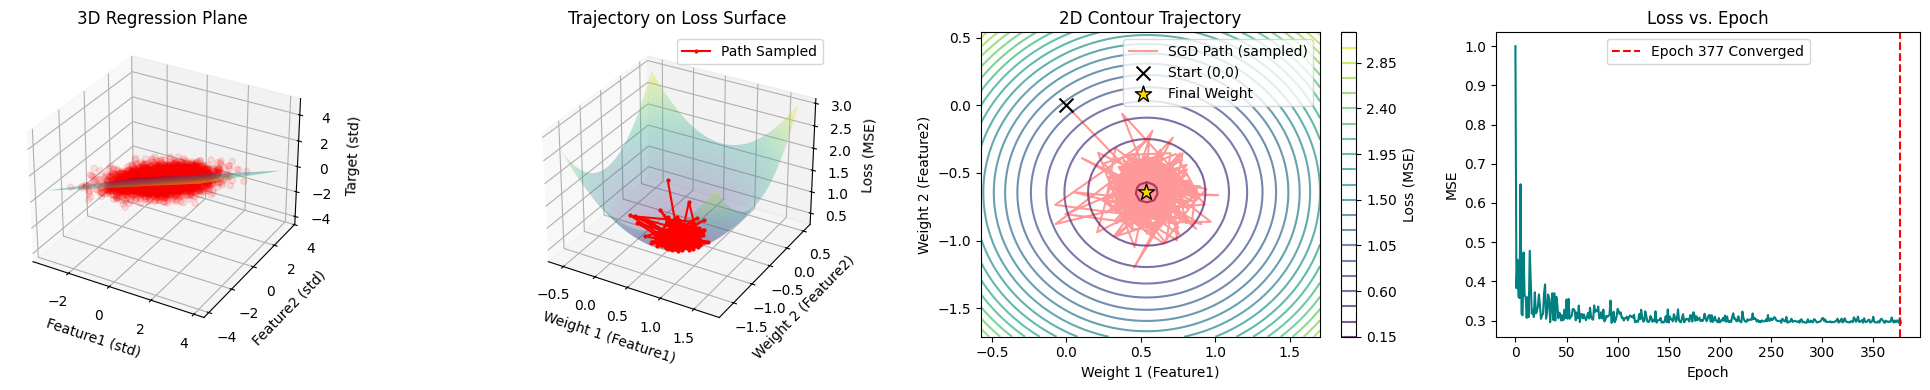

In [ ]:
x0_grid, x1_grid = np.meshgrid(
    np.linspace(X_std[:,0].min(), X_std[:,0].max(), 20),
    np.linspace(X_std[:,1].min(), X_std[:,1].max(), 20)
)

X_grid = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
y_grid = (X_grid @ w_final) + b_final
y_grid = y_grid.reshape(x0_grid.shape)

fig = plt.figure(figsize=(20, 4))

ax1 = fig.add_subplot(1, 4, 1, projection='3d')

ax1.scatter(X_std[:,0], X_std[:,1], y_std, color='red', alpha=0.1, label='Data points')
ax1.plot_surface(x0_grid, x1_grid, y_grid, alpha=0.5, cmap='viridis')
ax1.set_xlabel('Feature1 (std)')
ax1.set_ylabel('Feature2 (std)')
ax1.set_zlabel('Target (std)')
ax1.set_title('3D Regression Plane')

# trajectory in Parameter Space (3D)
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
# path_sampled = path[::50]
w1_path = np.array([p[0][0] for p in path])
w2_path = np.array([p[0][1] for p in path])
w1_range = np.linspace(min(w1_path)-0.5, max(w1_path)+0.5, 50)
w2_range = np.linspace(min(w2_path)-0.5, max(w2_path)+0.5, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_loss = np.array([np.mean((w1 * X_std[:,0] + w2 * X_std[:,1] + b_final - y_std.ravel())**2) for w1, w2 in zip(np.ravel(W1), np.ravel(W2))]).reshape(W1.shape)

ax2.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.3, antialiased=True)
loss_path = [np.mean((X_std @ p[0] + p[1] - y_std.ravel())**2) for p in path]
ax2.plot(w1_path[::5], w2_path[::5], loss_path[::5], color='red', marker='o', markersize=2, label='Path Sampled', zorder=10)
ax2.set_title("Trajectory on Loss Surface")
ax2.set_xlabel("Weight 1 (Feature1)")
ax2.set_ylabel("Weight 2 (Feature2)")
ax2.set_zlabel("Loss (MSE)")
ax2.legend()

# Trajectory in Contour (2D Projection)
ax3 = fig.add_subplot(1, 4, 3)
contour = ax3.contour(W1, W2, Z_loss, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax3, label='Loss (MSE)')
ax3.plot(w1_path[::5], w2_path[::5], 'r-', alpha=0.4, label='SGD Path (sampled)')
ax3.scatter(w1_path[0], w2_path[0], color='black', marker='x', s=100, label="Start (0,0)", zorder=5)
ax3.scatter(w_final[0], w_final[1], color='gold', edgecolors='black', s=150, marker='*', label='Final Weight', zorder=5)
ax3.set_title("2D Contour Trajectory")
ax3.set_xlabel("Weight 1 (Feature1)")
ax3.set_ylabel("Weight 2 (Feature2)")
ax3.legend()

# Convergence Curve
ax4 = fig.add_subplot(1, 4, 4)
ax4.plot(losses, color='teal')
ax4.axvline(x=converged_epoch-1, color='red', linestyle='--', label=f"Epoch {converged_epoch} Converged")
ax4.set_title("Loss vs. Epoch")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("MSE")
ax4.legend()

plt.tight_layout()
plt.show()

The visualization illustrates the characteristic behavior of Stochastic Gradient Descent (SGD) when applied to linear regression with Mean Squared Error (MSE). The 3D regression plane confirms that the model successfully fits the standardized data, while the loss surface in parameter space forms a smooth convex bowl, as expected for MSE. The trajectory plot shows a lot of oscillations around the optimal region. This jitter near the minimum is not an error but a defining property of SGD: because updates are computed from individual samples rather than the full dataset, the gradient contains inherent noise. As a result, SGD does not settle exactly at the minimum but instead fluctuates within a neighborhood of it and the oscillation decreases with learning rate decay.

The loss-versus-epoch curve further reflects this behavior, displaying an overall downward trend with noticeable variability, highlighting the stochastic nature of the optimization process.

Together, these plots provide a clear geometric and dynamic interpretation of how SGD converges in expectation while maintaining persistent variance near the optimum.

In [ ]:
real_w_sgd = w_final * (y_sigma / X_sigma)
real_b_sgd = y_mu + y_sigma * b_final - np.sum(real_w_sgd * X_mu)
print(f"Real Equation (Ground Truth): y = {real_w[0]:.2f}*Feature1 + {real_w[1]:.2f}*Feature2 + {real_b:.2f}")
print(f"Real Equation (Batch Gradient Descent): y = {real_w_bgd[0]:.2f}*Feature1 + {real_w_bgd[1]:.2f}*Feature2 + {real_b_bgd:.2f}")
print(f"Real Equation (Stochastic Gradient Descent): y = {real_w_sgd[0]:.2f}*Feature1 + {real_w_sgd[1]:.2f}*Feature2 + {real_b_sgd:.2f}")

Real Equation (Ground Truth): y = 2.99*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Batch Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Stochastic Gradient Descent): y = 2.98*Feature1 + -0.70*Feature2 + 0.03


In [ ]:
y_pred_sgd = X @ real_w_sgd + real_b_sgd
mse_sgd = np.mean((y - y_pred_sgd)**2)

print(f"Mean Squared Error (Batch Gradient Descent): {mse_bgd}")
print(f"Mean Squared Error (Stochastic Gradient Descent): {mse_sgd}")


Mean Squared Error (Batch Gradient Descent): 8.976412726722632
Mean Squared Error (Stochastic Gradient Descent): 8.975822177884899


Now we have seen the two extremes of the optimization spectrum. On one hand, Batch Gradient Descent provides a stable path to the minimum but collapses under the weight of big data because it requires the entire dataset for every single update. On the other, Stochastic Gradient Descent is incredibly fast and helps skip over local minima but its zig-zag path can be erractic and difficult to tune.

Let's enter the world of mini-batch gradient descent where we don't choose between total certainty and total chaos, we combine both into one. It is the industry standard for modern deep learning. In this case, we look at small representative "mini-batch" of data points typically between 32 and 512 samples.

## 2. Mini-Batch Gradient Descent

We choose mini-batch gradient descent because by averaging the gradient over a mini-batch, we smooth out the noise of SGD which leads to more stable convergence than pure SGD while still being significantly faster than batch gradient descent. The slight noise remaining in mini-batches actually acts as a form of regularization which helps the model generalize better to unseen data.

In Mini-batch GD, we split out training set into $n$ mini batches of size $b$. The update rule for mini-batch $B$ is:
$$
\theta_j := \theta_j - \alpha \frac{1}{b} \sum_{i \in B} \nabla_{\theta_j} J(\theta;x_i,y_i)
$$

where:
- $b$ is the batch size which is the critical hyperparameter we tune
- the gradient is the average of the losses within that specific batch

In [ ]:
def minibatch_gradient_descent(X, y, learning_rate = 0.001, epochs=50, batch_size=32, conv_threshold=1e-4, lr_decay=None):

  m, n = X.shape
  weights = np.zeros(n)
  bias = 0

  history = [(weights.copy(), float(bias))]
  loss_history = []
  converged = False
  converged_epoch = epochs
  y_flat = y.ravel()

  for epoch in range(epochs):
    indices = np.random.permutation(m)
    X_shuffled = X[indices]
    y_shuffled = y_flat[indices]

    if lr_decay is not None:
      lr = learning_rate / (1 + lr_decay * epoch)
    else:
      lr = learning_rate

    for i in range(0, m, batch_size):
      xi_batch = X_shuffled[i:i+batch_size]
      yi_batch = y_shuffled[i:i+batch_size]

      predictions = xi_batch @ weights + bias
      errors = predictions - yi_batch

      dw = (2 / len(yi_batch)) * (xi_batch.T @ errors)
      db = (2 / len(yi_batch)) * np.sum(errors)

      weights -= lr * dw
      bias -= lr * db

      history.append((weights.copy(), float(bias)))

    full_preds = X @ weights + bias
    mse = np.mean((full_preds - y_flat)**2)
    loss_history.append(mse)

    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < conv_threshold:
      converged_epoch = epoch + 1
      print(f"Converged after {epoch + 1} epochs.")
      converged = True
      break

  if not converged:
    print("Mini-batch gradient descent did not converge...")
    print("The optimization budget was exhausted before the minimum was reached.")
    print("Consider these adjustments:")
    print(f"Increase Learning Rate (Current: {learning_rate}): The hiker might be taking steps too small.")
    print(f"Increase Epochs (Current: {epochs}): The hiker might just need more time.")
    print(f"Loosen Convergence Threshold (Current: {conv_threshold}): Might be asking for a precision the data can't provide.")
    print(f"Reduce Batch Size (Current: {batch_size}): Smaller batches add noise that can help shake out of plateaus.")

  return weights, bias, history, loss_history, converged_epoch


In [ ]:
# Run Mini-Batch GD
w_final, b_final, path, losses, converged_epoch = minibatch_gradient_descent(X_std, y_std, learning_rate = 0.1, lr_decay = 0.05,
                                                                             epochs=5000, batch_size=16, conv_threshold=1e-5)

# note look at loss curve without lr_decay on here and SGD as well

Converged after 76 epochs.


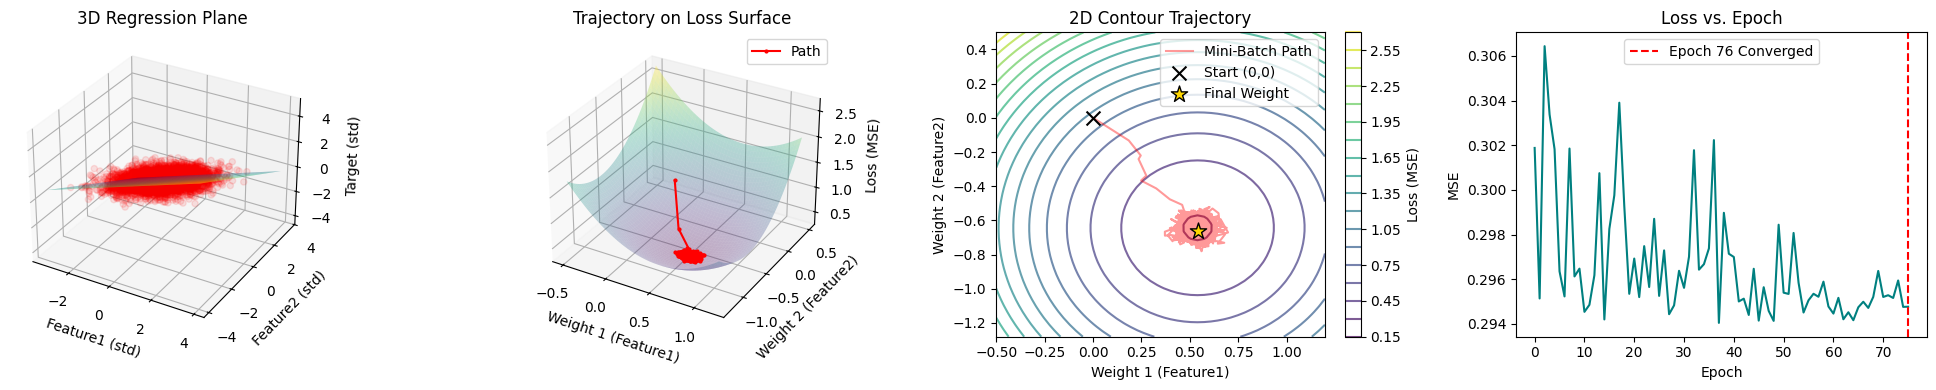

In [ ]:
x0_grid, x1_grid = np.meshgrid(
    np.linspace(X_std[:,0].min(), X_std[:,0].max(), 20),
    np.linspace(X_std[:,1].min(), X_std[:,1].max(), 20)
)

X_grid = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
y_grid = (X_grid @ w_final) + b_final
y_grid = y_grid.reshape(x0_grid.shape)

fig = plt.figure(figsize=(20, 4))

ax1 = fig.add_subplot(1, 4, 1, projection='3d')

ax1.scatter(X_std[:,0], X_std[:,1], y_std, color='red', alpha=0.1, label='Data points')
ax1.plot_surface(x0_grid, x1_grid, y_grid, alpha=0.5, cmap='viridis')
ax1.set_xlabel('Feature1 (std)')
ax1.set_ylabel('Feature2 (std)')
ax1.set_zlabel('Target (std)')
ax1.set_title('3D Regression Plane')

# trajectory in Parameter Space (3D)
ax2 = fig.add_subplot(1, 4, 2, projection='3d')

w1_path = np.array([p[0][0] for p in path])
w2_path = np.array([p[0][1] for p in path])
w1_range = np.linspace(min(w1_path)-0.5, max(w1_path)+0.5, 50)
w2_range = np.linspace(min(w2_path)-0.5, max(w2_path)+0.5, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_loss = np.array([np.mean((w1 * X_std[:,0] + w2 * X_std[:,1] + b_final - y_std.ravel())**2) for w1, w2 in zip(np.ravel(W1), np.ravel(W2))]).reshape(W1.shape)

ax2.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.3, antialiased=True)
loss_path = [np.mean((X_std @ p[0] + p[1] - y_std.ravel())**2) for p in path]
ax2.plot(w1_path[::5], w2_path[::5], loss_path[::5], color='red', marker='o', markersize=2, label='Path', zorder=10)
ax2.set_title("Trajectory on Loss Surface")
ax2.set_xlabel("Weight 1 (Feature1)")
ax2.set_ylabel("Weight 2 (Feature2)")
ax2.set_zlabel("Loss (MSE)")
ax2.legend()

# Trajectory in Contour (2D Projection)
ax3 = fig.add_subplot(1, 4, 3)
contour = ax3.contour(W1, W2, Z_loss, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax3, label='Loss (MSE)')
ax3.plot(w1_path, w2_path, 'r-', alpha=0.4, label='Mini-Batch Path')
ax3.scatter(w1_path[0], w2_path[0], color='black', marker='x', s=100, label="Start (0,0)", zorder=5)
ax3.scatter(w_final[0], w_final[1], color='gold', edgecolors='black', s=150, marker='*', label='Final Weight', zorder=5)
ax3.set_title("2D Contour Trajectory")
ax3.set_xlabel("Weight 1 (Feature1)")
ax3.set_ylabel("Weight 2 (Feature2)")
ax3.legend()

# Convergence Curve
ax4 = fig.add_subplot(1, 4, 4)
ax4.plot(losses, color='teal')
ax4.axvline(x=converged_epoch-1, color='red', linestyle='--', label=f"Epoch {converged_epoch} Converged")
ax4.set_title("Loss vs. Epoch")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("MSE")
ax4.legend()

plt.tight_layout()
plt.show()
# plt.savefig("mini-batch.jpg")

In [ ]:
real_w_mbgd = w_final * (y_sigma / X_sigma)
real_b_mbgd = y_mu + y_sigma * b_final - np.sum(real_w_mbgd * X_mu)
print(f"Real Equation (Ground Truth): y = {real_w[0]:.2f}*Feature1 + {real_w[1]:.2f}*Feature2 + {real_b:.2f}")
print(f"Real Equation (Batch Gradient Descent): y = {real_w_bgd[0]:.2f}*Feature1 + {real_w_bgd[1]:.2f}*Feature2 + {real_b_bgd:.2f}")
print(f"Real Equation (Stochastic Gradient Descent): y = {real_w_sgd[0]:.2f}*Feature1 + {real_w_sgd[1]:.2f}*Feature2 + {real_b_sgd:.2f}")
print(f"Real Equation (Mini-Batch Gradient Descent): y = {real_w_mbgd[0]:.2f}*Feature1 + {real_w_mbgd[1]:.2f}*Feature2 + {real_b_mbgd:.2f}")

Real Equation (Ground Truth): y = 2.99*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Batch Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Stochastic Gradient Descent): y = 2.98*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Mini-Batch Gradient Descent): y = 3.02*Feature1 + -0.72*Feature2 + 0.13


In [ ]:
y_pred_mbgd = X @ real_w_mbgd + real_b_mbgd
mse_mbgd = np.mean((y - y_pred_mbgd)**2)

print(f"Mean Squared Error (Batch Gradient Descent): {mse_bgd}")
print(f"Mean Squared Error (Stochastic Gradient Descent): {mse_sgd}")
print(f"Mean Squared Error (Mini-Batch Gradient Descent): {mse_mbgd}")

Mean Squared Error (Batch Gradient Descent): 8.976412726722632
Mean Squared Error (Stochastic Gradient Descent): 8.975822177884899
Mean Squared Error (Mini-Batch Gradient Descent): 8.998176641141121


In the first plot, the line passes through the center of the data points which means that our weights and bias have successfully captured the underlying trend. The orange line shows that despite only looking at 8 samples at a time, the model learned the global truth of this dataset.

In the second plot, we can see how the path is not perfectly straight. It vibrates because each mini-batch has a slightly different opinion on where the bottom is. Unlike batch GD, which moves slowly but surely, mini-batch takes many more steps in the same amount of time, allowing it to navigate the curves of the loss surface much faster. Notice how Batch Gradient Descent is smoother than Stochastic Gradient Descent.

In the third plot that is convergence curve, it tracks the progress. We can see that initially the MSE bounces around a lot and slowly decreases but never settles down.

Note, we have a problem here as well. We saw that mini-batch gradient descent eventually reaches the minimum, but its progress slows and oscillates near the valley.

Instead of letting each step forget the past, we can introduce memory into the system. This idea leads us to momentum, a method that accumulates velocity and smooths the optimization trajectory.

Now, we are going to give our hiker a pair of skis (sense of inertia). We are not just going to look at the gradient of the current step, we are going to remember the direction of the previous steps as well. We are going to add velocity to gradient descent to remember where we have been going and build up speed.

## 3. Momentum

Let's take a heavy metal ball as an example. Because of its mass, it does not immediately change direction when it hits a small bump. Instead, it accumulates speed in the directions where the gradient is consistent and cancels out the speed in directions where the gradient keeps flipping (the oscillations).

Mathematically, we introduce a Velocity vector (v):

- Step 1: Update velocity that is, combine previous velocity with current gradient.

$$
v_t = \beta v_{t-1} + (1 - \beta) \nabla_{\theta} J(\theta)
$$

- Step 2: Update weights that is, move in direction of velocity

$$
\theta = \theta - \alpha v_t
$$

where:
- $\beta$ (usually 0.9) is the momentum coefficient. It determines how much of the past/history to remember. $\beta=0.9$ means keep $90\%$ of previous velocity. It acts like friction which means higher $\beta=$ less friction.

$v_t$ becomes an exponentially weighted average of all the past gradients. Recent gradients matter most but the accumulated history gives us direction and speed.

To see why this works so effectively, let us unroll the recurrence. By substituting the expression for $v_{t-1}$ into the equation for $v_t$, we can see the contribution of every past gradient to our current step.

If we assume we start at $v_0 = 0$, the unrolling looks like this:

$$
v_t = (1 - \beta)\nabla_{\theta} J(\theta_t) + \beta v_{t-1}
$$

$$
v_t = (1 - \beta)\nabla_{\theta} J(\theta_t) + \beta[(1-\beta)\nabla_{\theta} J(\theta_{t-1}) + \beta v_{t-2}]
$$

Continuing this patten all the way back to the first step we get:

$$
v_t = (1-\beta)[\nabla_{\theta} J(\theta_t) + \beta \nabla_{\theta} J(\theta_{t-1}) + \beta^2\nabla_{\theta} J(\theta_{t-2})+...+\beta^{t-1}\nabla_{\theta}J(\theta_1)]
$$

Notice the coefficients $(1-\beta), \beta(1-\beta), \beta^2(1-\beta),...$. Since $\beta < 1$, the powers of $\beta$ get smaller as we go further back in time. This means the most recent gradients have the biggest impact on our direction while the memory of older gradients slowly fades away. Mathematically, this is an exponentially weighted moving average. A good rule of thumb is that $v_t$ is approximately averaging over the last $\frac{1}{1 - \beta}$ iterations. If $\beta = 0.9$, we are averaging over the last 10 gradients. And if $\beta = 0.99$ then we are averaging over the last 100 gradients. In the osicalltions, the gradients in the vertical direction keep flipping signs and when we average them, they cancel each other out damping the bounce. And on the slope (consistent direction), the gradients in the horizontal direction all point the same way. When we average them, they add up, causing the hiker to accelerate towards the minimum.

In [ ]:
def minibatch_momentum_gd(X, y, learning_rate=0.01, beta=0.9, epochs=100, batch_size=32, conv_threshold = 0.00001, lr_decay=None):
  m, n = X.shape
  weights = np.zeros(n)
  bias = 0

  v_w = np.zeros(n) # initialize velocity weights
  v_b = 0

  history = [(weights.copy(), float(bias))]
  loss_history = []
  converged = False
  converged_epoch = epochs
  y_flat = y.ravel()

  for epoch in range(epochs):
    indices = np.random.permutation(m)
    X_shuffled = X[indices]
    y_shuffled = y_flat[indices]

    if lr_decay is not None:
      lr = learning_rate / (1 + lr_decay * epoch)
    else:
      lr = learning_rate

    for i in range(0, m, batch_size):
      xi_batch = X_shuffled[i:i+batch_size]
      yi_batch = y_shuffled[i:i+batch_size]

      history.append((weights.copy(), float(bias)))

      predictions = xi_batch @ weights + bias
      errors = predictions - yi_batch

      dw = (2 / len(yi_batch)) * (xi_batch.T @ errors)
      db = (2 / len(yi_batch)) * np.sum(errors)

      # momentum update
      v_w = beta * v_w + (1 - beta) * dw # update velocities (exponentially weighted average of gradients)
      v_b = beta * v_b + (1 - beta) * db

      weights -= lr * v_w # update weights using the momentum instead of raw gradients
      bias -= lr * v_b

    # epoch level logging
    full_preds = X @ weights + bias
    mse = np.mean((full_preds - y_flat)**2)
    loss_history.append(mse)

    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < conv_threshold:
      converged_epoch = epoch + 1
      print(f"Momentum Converged after {converged_epoch} epochs.")
      converged = True
      break
  if not converged:
    print("Momentum GD has not converged...")
    print("Even with a heavy ball, the hiker is still on the slopes. Consider:")
    print(f"Increasing Learning Rate (Current: {learning_rate})")
    print(f"Adjusting Momentum Beta (Current: {beta})")

  return weights, bias, history, loss_history, converged_epoch

In [ ]:
w_final, b_final, path, losses, converged_epoch = minibatch_momentum_gd(X_std, y_std, learning_rate=0.1, beta=0.9, epochs=5000,
                                                                        batch_size=16, conv_threshold = 1e-6, lr_decay=0.01)

Momentum Converged after 505 epochs.


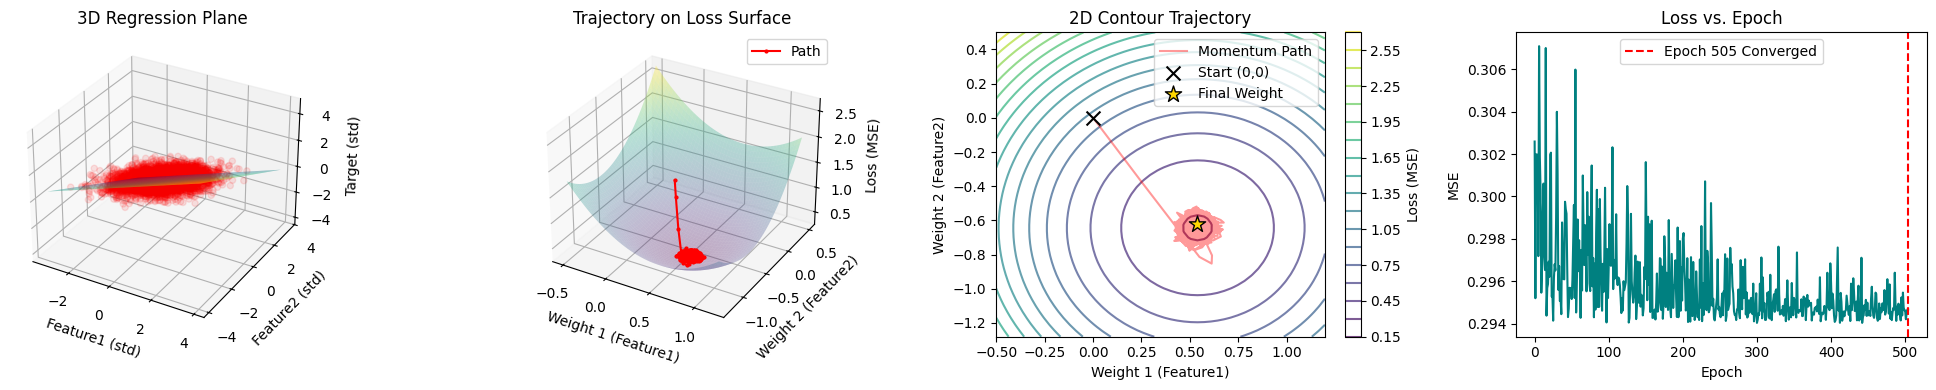

In [ ]:
x0_grid, x1_grid = np.meshgrid(
    np.linspace(X_std[:,0].min(), X_std[:,0].max(), 20),
    np.linspace(X_std[:,1].min(), X_std[:,1].max(), 20)
)

X_grid = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
y_grid = (X_grid @ w_final) + b_final
y_grid = y_grid.reshape(x0_grid.shape)

fig = plt.figure(figsize=(20, 4))

ax1 = fig.add_subplot(1, 4, 1, projection='3d')

ax1.scatter(X_std[:,0], X_std[:,1], y_std, color='red', alpha=0.1, label='Data points')
ax1.plot_surface(x0_grid, x1_grid, y_grid, alpha=0.5, cmap='viridis')
ax1.set_xlabel('Feature1 (std)')
ax1.set_ylabel('Feature2 (std)')
ax1.set_zlabel('Target (std)')
ax1.set_title('3D Regression Plane')

# trajectory in Parameter Space (3D)
ax2 = fig.add_subplot(1, 4, 2, projection='3d')

w1_range = np.linspace(min(w1_path)-0.5, max(w1_path)+0.5, 50)
w2_range = np.linspace(min(w2_path)-0.5, max(w2_path)+0.5, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_loss = np.array([np.mean((w1 * X_std[:,0] + w2 * X_std[:,1] + b_final - y_std.ravel())**2) for w1, w2 in zip(np.ravel(W1), np.ravel(W2))]).reshape(W1.shape)

ax2.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.3, antialiased=True)
w1_path = np.array([p[0][0] for p in path])
w2_path = np.array([p[0][1] for p in path])
loss_path = [np.mean((X_std @ p[0] + p[1] - y_std.ravel())**2) for p in path]
ax2.plot(w1_path[::5], w2_path[::5], loss_path[::5], color='red', marker='o', markersize=2, label='Path', zorder=10)
ax2.set_title("Trajectory on Loss Surface")
ax2.set_xlabel("Weight 1 (Feature1)")
ax2.set_ylabel("Weight 2 (Feature2)")
ax2.set_zlabel("Loss (MSE)")
ax2.legend()

# Trajectory in Contour (2D Projection)
ax3 = fig.add_subplot(1, 4, 3)
contour = ax3.contour(W1, W2, Z_loss, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax3, label='Loss (MSE)')
ax3.plot(w1_path[::5], w2_path[::5], 'r-', alpha=0.4, label='Momentum Path')
ax3.scatter(w1_path[0], w2_path[0], color='black', marker='x', s=100, label="Start (0,0)", zorder=5)
ax3.scatter(w_final[0], w_final[1], color='gold', edgecolors='black', s=150, marker='*', label='Final Weight', zorder=5)
ax3.set_title("2D Contour Trajectory")
ax3.set_xlabel("Weight 1 (Feature1)")
ax3.set_ylabel("Weight 2 (Feature2)")
ax3.legend()

# Convergence Curve
ax4 = fig.add_subplot(1, 4, 4)
ax4.plot(losses, color='teal')
ax4.axvline(x=converged_epoch-1, color='red', linestyle='--', label=f"Epoch {converged_epoch} Converged")
ax4.set_title("Loss vs. Epoch")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("MSE")
ax4.legend()

plt.tight_layout()
plt.show()

In the middle plot above, notice how the path looks like a car taking a smooth line through a turn. Unlike the noisy path of mini-batch, momentum uses its accumulated velocity to smooth out the noise from individual batches

In the right plot we can see that since we are rolling with speed, the loss often drops more aggressively and oscillates once it reaches near the minimum compared to the standard gradient descent.

In [ ]:
real_w_mgd = w_final * (y_sigma / X_sigma)
real_b_mgd = y_mu + y_sigma * b_final - np.sum(real_w_mgd * X_mu)
print(f"Real Equation (Ground Truth): y = {real_w[0]:.2f}*Feature1 + {real_w[1]:.2f}*Feature2 + {real_b:.2f}")
print(f"Real Equation (Batch Gradient Descent): y = {real_w_bgd[0]:.2f}*Feature1 + {real_w_bgd[1]:.2f}*Feature2 + {real_b_bgd:.2f}")
print(f"Real Equation (Stochastic Gradient Descent): y = {real_w_sgd[0]:.2f}*Feature1 + {real_w_sgd[1]:.2f}*Feature2 + {real_b_sgd:.2f}")
print(f"Real Equation (Mini-Batch Gradient Descent): y = {real_w_mbgd[0]:.2f}*Feature1 + {real_w_mbgd[1]:.2f}*Feature2 + {real_b_mbgd:.2f}")
print(f"Real Equation (Momentum Gradient Descent): y = {real_w_mgd[0]:.2f}*Feature1 + {real_w_mgd[1]:.2f}*Feature2 + {real_b_mgd:.2f}")

Real Equation (Ground Truth): y = 2.99*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Batch Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Stochastic Gradient Descent): y = 2.98*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Mini-Batch Gradient Descent): y = 3.02*Feature1 + -0.72*Feature2 + 0.13
Real Equation (Momentum Gradient Descent): y = 2.98*Feature1 + -0.68*Feature2 + -0.05


In [ ]:
y_pred_mgd = X @ real_w_mgd + real_b_mgd
mse_mgd = np.mean((y - y_pred_mgd)**2)

print(f"Mean Squared Error (Batch Gradient Descent): {mse_bgd}")
print(f"Mean Squared Error (Stochastic Gradient Descent): {mse_sgd}")
print(f"Mean Squared Error (Mini-Batch Gradient Descent): {mse_mbgd}")
print(f"Mean Squared Error (Momentum Gradient Descent): {mse_mgd}")

Mean Squared Error (Batch Gradient Descent): 8.976412726722632
Mean Squared Error (Stochastic Gradient Descent): 8.975822177884899
Mean Squared Error (Mini-Batch Gradient Descent): 8.998176641141121
Mean Squared Error (Momentum Gradient Descent): 8.9953566802633


In momentum based gradient descent, we gave our hiker skis (momentum) to glide through the noise but there is still one more major hurdle in the landscape of optimization and that is *The Scale Problem*.

In a typical neural network, some weights might be connected to features that vary wildly (causing steep, treacherous cliffs in the loss surface), while others are connected to features that barely change (creating long, flat, boring plains). If we use a large learning rate, we might fly off the cliffs. If we use a small one, we will never cross the plains. Up until now, we have used a single learning rate $\alpha$ and slowing decaying it as it reaches the minimum for every parameter in our model.

Now, we will use the adaptive learning rate by giving each parameter its own individual learning rate which helps us normalize the terrain.

## 4. RMS Prop: The Adaptive Hiker

Introduced by Geoffrey Hinton (often called the "Godfather of AI"), RMSProp (Root Mean Square Propagation) solves this by giving each parameter its own individual, adaptive learning rate. Instead of looking at the direction of the gradient (like Momentum), RMSProp scales the learning rate for each parameter by a running average of the magnitudes of its recent gradients.

Instead of tracking the direction (like the velocity in Momentum), we track the "vibrancy" or scale of the gradient by maintaining a moving average of its square.

$$
s_t = \beta s_{t-1} + (1 - \beta)g_t^2
$$

where:

- $g_t = \nabla_{\theta}J(\theta)$ is the current gradient.
- $\beta$ (typically 0.9) is the decay rate, determining how far back we look to judge the steepness.
- $s_t$ serves as a cache of the gradient's energy. Squaring the gradient ensures that $s_t$ is always positive, focusing strictly on magnitude regardless of direction

We then update the weights by dividing the global learning rate $\alpha$ by the root of this cache.

$$
\theta_{t+1}  = \theta_t - \frac{\alpha}{\sqrt(s_t) + \epsilon}g_t
$$

where:
- $\epsilon$ (typically $10^{-8}$) is a fuzz factor added to ensure numerical stability and avoid division by zero.

The beauty of this formulation lies in its self-regulating nature. In steep directions, $g_t$ is large, making $s_t$ large. Dividing by $\sqrt(s_t)$ effectively shrinks the learning rate, preventing the hiker from flying off a cliff. In flat directions, $g_t$ is small, making $s_t$ small. Dividng by a small number amplifies the learning rate, pushing the hiker to speed through the plateau.

In [ ]:
# automatic gear shifter - RMSProp

def minibatch_rmsprop_gd(X, y, learning_rate=0.001, beta=0.9, epochs=1000, batch_size=16, epsilon=1e-8, conv_threshold=1e-5, patience=10):
  m, n = X.shape
  weights = np.zeros(n)
  bias = 0

  s_w = np.zeros(n) # square gradient cache initialized to zero
  s_b = 0

  history = [(weights.copy(), float(bias))]
  loss_history = []
  converged = False
  converged_epoch = epochs
  y_flat = y.ravel()

  for epoch in range(epochs):
    indices = np.random.permutation(m)
    X_s, y_s = X[indices], y_flat[indices]

    for i in range(0, m, batch_size):
      xi = X_s[i:i+batch_size]
      yi = y_s[i:i+batch_size]

      error = (xi @ weights + bias) - yi
      dw = (2 / len(yi)) * (xi.T @ error)
      db = (2 / len(yi)) * np.sum(error)

      # rmsprop update
      s_w = beta * s_w + (1 - beta) * (dw**2) # update the moving average of squared gradients
      s_b = beta * s_b + (1 - beta) * (db**2)

      # adaptive step: divide by the root mean square (rms)
      weights -= (learning_rate / (np.sqrt(s_w) + epsilon)) * dw
      bias -= (learning_rate / (np.sqrt(s_b) + epsilon)) * db

      history.append((weights.copy(), float(bias)))

    # logging and convergence
    mse = np.mean((X@weights+bias-y_flat)**2)
    loss_history.append(mse)
    # Divergence guard
    if np.isnan(mse) or np.isinf(mse):
      raise FloatingPointError("Loss diverged. Reduce learning rate.")

    # if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < conv_threshold:
    #   converged_epoch = epoch + 1
    #   print(f"RMSProp Converged after {converged_epoch} epochs.")
    #   break

    # Convergence check (patience-based, more stable)
    if epoch > patience:
      recent_losses = loss_history[-(patience+1):]
      improvements = [abs((recent_losses[i] - recent_losses[i-1]) / (recent_losses[i-1] + 1e-12)) for i in range(1, len(recent_losses))]

      if all(improve < conv_threshold for improve in improvements):
        converged = True
        converged_epoch = epoch + 1
        print(f"RMSProp Converged after {converged_epoch} epochs.")
        break

  if not converged:
    print("RMSProp did not reach convergence threshold.")
    print("Possible adjustments:")
    print(f"Reduce learning rate (current: {learning_rate})")
    print(f"Adjust beta (current: {beta})")
    print("Increase epochs")
    print("Increase convergence threshold")
    print("Check feature scaling (RMSProp assumes reasonable scaling)")

  return weights, bias, history, loss_history, converged_epoch

In [ ]:
w_final, b_final, path, losses, converged_epoch = minibatch_rmsprop_gd(X_std, y_std, epochs=5000, learning_rate=0.001, conv_threshold=1e-3)

RMSProp Converged after 13 epochs.


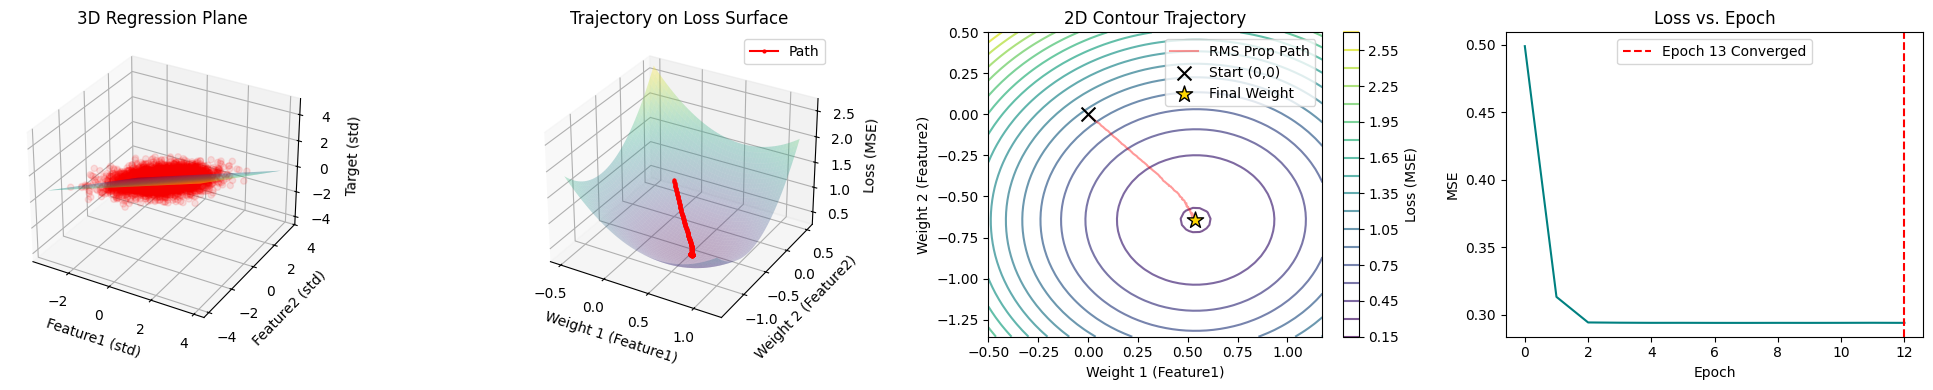

In [ ]:
x0_grid, x1_grid = np.meshgrid(
    np.linspace(X_std[:,0].min(), X_std[:,0].max(), 20),
    np.linspace(X_std[:,1].min(), X_std[:,1].max(), 20)
)

X_grid = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
y_grid = (X_grid @ w_final) + b_final
y_grid = y_grid.reshape(x0_grid.shape)

fig = plt.figure(figsize=(20, 4))

ax1 = fig.add_subplot(1, 4, 1, projection='3d')

ax1.scatter(X_std[:,0], X_std[:,1], y_std, color='red', alpha=0.1, label='Data points')
ax1.plot_surface(x0_grid, x1_grid, y_grid, alpha=0.5, cmap='viridis')
ax1.set_xlabel('Feature1 (std)')
ax1.set_ylabel('Feature2 (std)')
ax1.set_zlabel('Target (std)')
ax1.set_title('3D Regression Plane')

# trajectory in Parameter Space (3D)
ax2 = fig.add_subplot(1, 4, 2, projection='3d')

w1_range = np.linspace(min(w1_path)-0.5, max(w1_path)+0.5, 50)
w2_range = np.linspace(min(w2_path)-0.5, max(w2_path)+0.5, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_loss = np.array([np.mean((w1 * X_std[:,0] + w2 * X_std[:,1] + b_final - y_std.ravel())**2) for w1, w2 in zip(np.ravel(W1), np.ravel(W2))]).reshape(W1.shape)

ax2.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.3, antialiased=True)
w1_path = np.array([p[0][0] for p in path])
w2_path = np.array([p[0][1] for p in path])
loss_path = [np.mean((X_std @ p[0] + p[1] - y_std.ravel())**2) for p in path]
ax2.plot(w1_path[::5], w2_path[::5], loss_path[::5], color='red', marker='o', markersize=2, label='Path', zorder=10)
ax2.set_title("Trajectory on Loss Surface")
ax2.set_xlabel("Weight 1 (Feature1)")
ax2.set_ylabel("Weight 2 (Feature2)")
ax2.set_zlabel("Loss (MSE)")
ax2.legend()

# Trajectory in Contour (2D Projection)
ax3 = fig.add_subplot(1, 4, 3)
contour = ax3.contour(W1, W2, Z_loss, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax3, label='Loss (MSE)')
ax3.plot(w1_path[::5], w2_path[::5], 'r-', alpha=0.4, label='RMS Prop Path')
ax3.scatter(w1_path[0], w2_path[0], color='black', marker='x', s=100, label="Start (0,0)", zorder=5)
ax3.scatter(w_final[0], w_final[1], color='gold', edgecolors='black', s=150, marker='*', label='Final Weight', zorder=5)
ax3.set_title("2D Contour Trajectory")
ax3.set_xlabel("Weight 1 (Feature1)")
ax3.set_ylabel("Weight 2 (Feature2)")
ax3.legend()

# Convergence Curve
ax4 = fig.add_subplot(1, 4, 4)
ax4.plot(losses, color='teal')
ax4.axvline(x=converged_epoch-1, color='red', linestyle='--', label=f"Epoch {converged_epoch} Converged")
ax4.set_title("Loss vs. Epoch")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("MSE")
ax4.legend()

plt.tight_layout()
plt.show()

In the trajectory plot, notice how RMSProp does not necessarily glide with momentum, but it moves very decisively. Because it scales the learning rate, it effectively reshapes the loss surface. It turns the narrow, steep "ravines" into nice, circular "bowls" where every direction is easier to navigate.

In [ ]:
real_w_rmsgd = w_final * (y_sigma / X_sigma)
real_b_rmsgd = y_mu + y_sigma * b_final - np.sum(real_w_rmsgd * X_mu)
print(f"Real Equation (Ground Truth): y = {real_w[0]:.2f}*Feature1 + {real_w[1]:.2f}*Feature2 + {real_b:.2f}")
print(f"Real Equation (Batch Gradient Descent): y = {real_w_bgd[0]:.2f}*Feature1 + {real_w_bgd[1]:.2f}*Feature2 + {real_b_bgd:.2f}")
print(f"Real Equation (Stochastic Gradient Descent): y = {real_w_sgd[0]:.2f}*Feature1 + {real_w_sgd[1]:.2f}*Feature2 + {real_b_sgd:.2f}")
print(f"Real Equation (Mini-Batch Gradient Descent): y = {real_w_mbgd[0]:.2f}*Feature1 + {real_w_mbgd[1]:.2f}*Feature2 + {real_b_mbgd:.2f}")
print(f"Real Equation (Momentum Gradient Descent): y = {real_w_mgd[0]:.2f}*Feature1 + {real_w_mgd[1]:.2f}*Feature2 + {real_b_mgd:.2f}")
print(f"Real Equation (RMS Prop Gradient Descent): y = {real_w_rmsgd[0]:.2f}*Feature1 + {real_w_rmsgd[1]:.2f}*Feature2 + {real_b_rmsgd:.2f}")

Real Equation (Ground Truth): y = 2.99*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Batch Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Stochastic Gradient Descent): y = 2.98*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Mini-Batch Gradient Descent): y = 3.02*Feature1 + -0.72*Feature2 + 0.13
Real Equation (Momentum Gradient Descent): y = 2.98*Feature1 + -0.68*Feature2 + -0.05
Real Equation (RMS Prop Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + -0.01


In [ ]:
y_pred_rmsgd = X @ real_w_rmsgd + real_b_rmsgd
mse_rmsgd = np.mean((y - y_pred_rmsgd)**2)

print(f"Mean Squared Error (Batch Gradient Descent): {mse_bgd}")
print(f"Mean Squared Error (Stochastic Gradient Descent): {mse_sgd}")
print(f"Mean Squared Error (Mini-Batch Gradient Descent): {mse_mbgd}")
print(f"Mean Squared Error (Momentum Gradient Descent): {mse_mgd}")
print(f"Mean Squared Error (RMS Prop Gradient Descent): {mse_rmsgd}")

Mean Squared Error (Batch Gradient Descent): 8.976412726722632
Mean Squared Error (Stochastic Gradient Descent): 8.975822177884899
Mean Squared Error (Mini-Batch Gradient Descent): 8.998176641141121
Mean Squared Error (Momentum Gradient Descent): 8.9953566802633
Mean Squared Error (RMS Prop Gradient Descent): 8.977642662418015


We have now seen two distinct ways to improve upon basic gradient descent: Momentum (which handles the direction and inertia of our steps) and RMSProp (which handles the scaling and terrain of the landscape).

In the world of optimization, these were two separate breakthrough ideas. But in 2014, a paper titled *Adam: A Method for Stochastic Optimization* proposed a revolutionary synthesis. If momentum is our "skis" and RMSProp is our "Adaptive Gear Shifter", why not use both?

## 5. Adam: The intelligent Optimizer

Adam (Adaptive Moment Estimation) is currently the gold standard in deep learning. It combines the advantages of Momentum and RMSProp into a single unified framework that tracks both the velocity of the descent and the scale of the terrain simultaneously.

Adam maintains two moving averages:
- The First Moment (the mean of gradients) and
- The Second Moment (the uncentered variance of gradients)


For each parameter, we update the first and second moments using exponential decay:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)g_t
$$
$$
v_t = \beta_2v_{t-1} + (1 - \beta_2)g_t^2
$$
where
- $m_t$ is the directional velocity.
- $v_t$ is the scaling cache.
- $\beta_1$ (typically 0.9) handles the Momentum
- $\beta_2$ (typically 0.999) handles the RMSProp scaling.

Since $m$ and $v$ are initialized to zero, they are biased toward zero during the initial training steps, especially when the decay rates are very high (close to 1). To prevent our optimizer from starting too slowly, we apply a bias correction.

$$
\hat m_t = \frac{m_t}{1 - \beta_1^t}
$$

and

$$
\hat v_t = \frac{v_t}{1 - \beta_2^t}
$$

As the number of steps ($t$) increases, the terms $\beta_1^t$ and $\beta_2^t$ approach zero, making the correction factor fade away. This ensures the optimizer is aggresive enough at the very beginning of the journey.

Finally, we combine these corrected moments into a single update rule:

$$
\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt(\hat v_t) + \epsilon}\hat m_t
$$

In [ ]:
# ADAM in action

def minibatch_adam_gd(X, y, learning_rate=0.0001, beta1=0.9, beta2=0.999, epochs=1000, batch_size=8, epsilon=1e-8, conv_threshold=1e-4):
  m, n = X.shape
  weights, bias = np.zeros(n), 0

  # initialize moments
  m_w, m_b = np.zeros(n), 0 # mean of gradients
  v_w, v_b = np.zeros(n), 0 # uncentered variance

  t = 0 # timestep counter for bias correction

  history = [(weights.copy(), float(bias))]
  loss_history = []
  converged = False
  converged_epoch = epochs
  y_flat = y.ravel()

  for epoch in range(epochs):
    indices = np.random.permutation(m)
    X_s, y_s = X[indices], y_flat[indices]

    for i in range(0, m, batch_size):
      t += 1 # increment time for bias correction
      xi, yi = X_s[i:i+batch_size], y_s[i:i+batch_size]

      # gradients
      dw = (2 / len(yi)) * (xi.T @ (xi @ weights + bias - yi))
      db = (2 / len(yi)) * np.sum((xi @ weights + bias) - yi)

      # update first moment (Momentum component)
      m_w = beta1 * m_w + (1 - beta1) * dw
      m_b = beta1 * m_b + (1 - beta1) * db

      # update second moment (RMSProp component / Scaling)
      v_w = beta2 * v_w + (1 - beta2) * (dw**2)
      v_b = beta2 * v_b + (1 - beta2) * (db**2)

      # apply bias correction ( corrects the cold start from 0 initialization)
      m_w_corr = m_w / (1 - beta1**t)
      m_b_corr = m_b / (1 - beta1**t)
      v_w_corr = v_w / (1 - beta2**t)
      v_b_corr = v_b / (1 - beta2**t)

      # final update
      weights -= (learning_rate / (np.sqrt(v_w_corr) + epsilon)) * m_w_corr
      bias -= (learning_rate / (np.sqrt(v_b_corr) + epsilon)) * m_b_corr

      history.append((weights.copy(), float(bias)))

    # Logging MSE after each epoch
    full_preds = X @ weights + bias
    mse = np.mean((full_preds - y_flat)**2)
    loss_history.append(mse)

    # Check for Convergence
    if epoch > 0 and abs(loss_history[-2] - loss_history[-1]) < conv_threshold:
      converged_epoch = epoch + 1
      print(f"Adam Converged after {converged_epoch} epochs.")
      converged = True
      break

  if not converged:
    print(" Adam has not converged...")
    print("Even the 'King of Optimizers' needs the right settings. Consider:")
    print(f"1. Increase Learning Rate (Current: {learning_rate}): Adam is often robust, but 0.001 might be too cautious.")
    print(f"2. Adjust Beta parameters: Beta1 (Current: {beta1}) or Beta2 (Current: {beta2}) might need tuning.")
    print("3. Check the Epsilon: Your threshold for 'progress' might be too tight for this data.")

  return weights, bias, history, loss_history, converged_epoch

In [ ]:
w_final, b_final, path, losses, converged_epoch = minibatch_adam_gd(X_std, y_std, learning_rate=0.0001)

Adam Converged after 22 epochs.


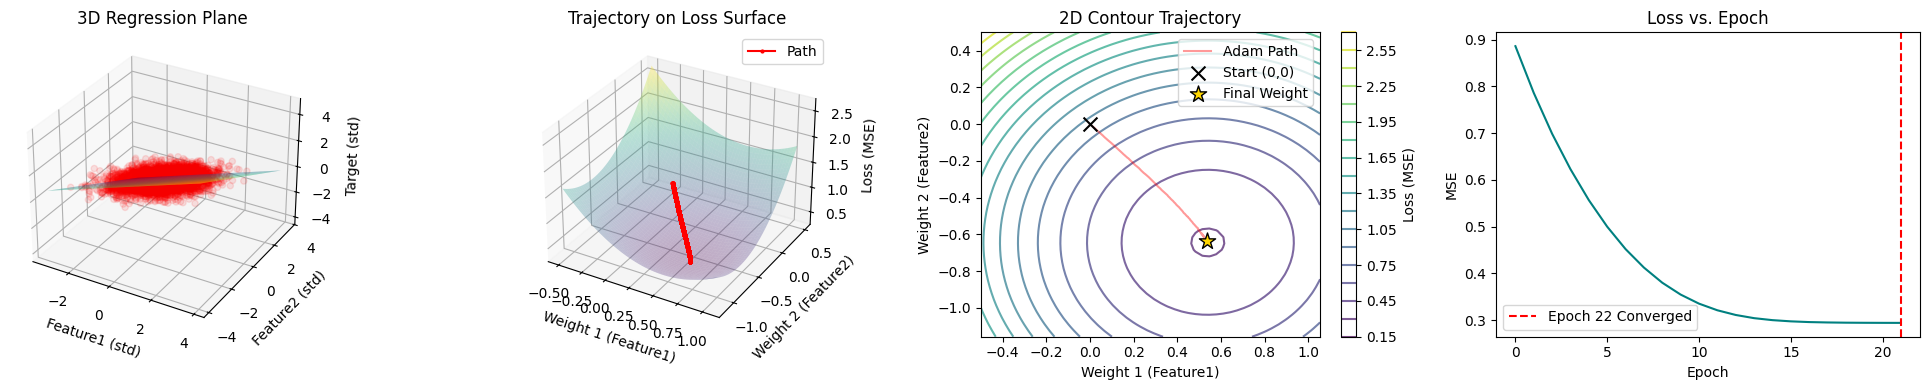

In [ ]:
x0_grid, x1_grid = np.meshgrid(
    np.linspace(X_std[:,0].min(), X_std[:,0].max(), 20),
    np.linspace(X_std[:,1].min(), X_std[:,1].max(), 20)
)

X_grid = np.column_stack([x0_grid.ravel(), x1_grid.ravel()])
y_grid = (X_grid @ w_final) + b_final
y_grid = y_grid.reshape(x0_grid.shape)

fig = plt.figure(figsize=(20, 4))

ax1 = fig.add_subplot(1, 4, 1, projection='3d')

ax1.scatter(X_std[:,0], X_std[:,1], y_std, color='red', alpha=0.1, label='Data points')
ax1.plot_surface(x0_grid, x1_grid, y_grid, alpha=0.5, cmap='viridis')
ax1.set_xlabel('Feature1 (std)')
ax1.set_ylabel('Feature2 (std)')
ax1.set_zlabel('Target (std)')
ax1.set_title('3D Regression Plane')

# trajectory in Parameter Space (3D)
ax2 = fig.add_subplot(1, 4, 2, projection='3d')

w1_range = np.linspace(min(w1_path)-0.5, max(w1_path)+0.5, 50)
w2_range = np.linspace(min(w2_path)-0.5, max(w2_path)+0.5, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)

Z_loss = np.array([np.mean((w1 * X_std[:,0] + w2 * X_std[:,1] + b_final - y_std.ravel())**2) for w1, w2 in zip(np.ravel(W1), np.ravel(W2))]).reshape(W1.shape)

ax2.plot_surface(W1, W2, Z_loss, cmap='viridis', alpha=0.3, antialiased=True)
w1_path = np.array([p[0][0] for p in path])
w2_path = np.array([p[0][1] for p in path])
loss_path = [np.mean((X_std @ p[0] + p[1] - y_std.ravel())**2) for p in path]
ax2.plot(w1_path[::5], w2_path[::5], loss_path[::5], color='red', marker='o', markersize=2, label='Path', zorder=10)
ax2.set_title("Trajectory on Loss Surface")
ax2.set_xlabel("Weight 1 (Feature1)")
ax2.set_ylabel("Weight 2 (Feature2)")
ax2.set_zlabel("Loss (MSE)")
ax2.legend()

# Trajectory in Contour (2D Projection)
ax3 = fig.add_subplot(1, 4, 3)
contour = ax3.contour(W1, W2, Z_loss, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, ax=ax3, label='Loss (MSE)')
ax3.plot(w1_path[::5], w2_path[::5], 'r-', alpha=0.4, label='Adam Path')
ax3.scatter(w1_path[0], w2_path[0], color='black', marker='x', s=100, label="Start (0,0)", zorder=5)
ax3.scatter(w_final[0], w_final[1], color='gold', edgecolors='black', s=150, marker='*', label='Final Weight', zorder=5)
ax3.set_title("2D Contour Trajectory")
ax3.set_xlabel("Weight 1 (Feature1)")
ax3.set_ylabel("Weight 2 (Feature2)")
ax3.legend()

# Convergence Curve
ax4 = fig.add_subplot(1, 4, 4)
ax4.plot(losses, color='teal')
ax4.axvline(x=converged_epoch-1, color='red', linestyle='--', label=f"Epoch {converged_epoch} Converged")
ax4.set_title("Loss vs. Epoch")
ax4.set_xlabel("Epoch")
ax4.set_ylabel("MSE")
ax4.legend()

plt.tight_layout()
plt.show()

Adam performance is best captured through the lens of efficiency and precision. In the regression line plot, we see the algorithm's ability to "lock in" on the ground truth with surgical accuracy, often outperforming simple methods on noisy datastes.

The trajectory plot reveals adam's true genius. A path is both smooth and decisive by utilizing bias-ocrrected momentum to power through the initial cold start and adaptive scaling to glide effortlessly toward the minimum without the erractic oscillations seen in SGD.

Finally, the loss vs epoch curve typically exhibits the steepest initial drop, serving as a testament to its speed. Together, these plots illustrate an optimizer that does not just find the solution, but does so by intelligently reshaping the landscape to find the most direct flight path to the valley floor.

In [ ]:
real_w_adamgd = w_final * (y_sigma / X_sigma)
X_mu = np.mean(X, axis=0)
real_b_adamgd = y_mu + y_sigma * b_final - np.sum(real_w_adamgd * X_mu)
print(f"Real Equation (Ground Truth): y = {real_w[0]:.2f}*Feature1 + {real_w[1]:.2f}*Feature2 + {real_b:.2f}")
print(f"Real Equation (Batch Gradient Descent): y = {real_w_bgd[0]:.2f}*Feature1 + {real_w_bgd[1]:.2f}*Feature2 + {real_b_bgd:.2f}")
print(f"Real Equation (Stochastic Gradient Descent): y = {real_w_sgd[0]:.2f}*Feature1 + {real_w_sgd[1]:.2f}*Feature2 + {real_b_sgd:.2f}")
print(f"Real Equation (Mini-Batch Gradient Descent): y = {real_w_mbgd[0]:.2f}*Feature1 + {real_w_mbgd[1]:.2f}*Feature2 + {real_b_mbgd:.2f}")
print(f"Real Equation (Momentum Gradient Descent): y = {real_w_mgd[0]:.2f}*Feature1 + {real_w_mgd[1]:.2f}*Feature2 + {real_b_mgd:.2f}")
print(f"Real Equation (RMS Prop Gradient Descent): y = {real_w_rmsgd[0]:.2f}*Feature1 + {real_w_rmsgd[1]:.2f}*Feature2 + {real_b_rmsgd:.2f}")
print(f"Real Equation (Adam Gradient Descent): y = {real_w_adamgd[0]:.2f}*Feature1 + {real_w_adamgd[1]:.2f}*Feature2 + {real_b_adamgd:.2f}")

Real Equation (Ground Truth): y = 2.99*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Batch Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Stochastic Gradient Descent): y = 2.98*Feature1 + -0.70*Feature2 + 0.03
Real Equation (Mini-Batch Gradient Descent): y = 3.02*Feature1 + -0.72*Feature2 + 0.13
Real Equation (Momentum Gradient Descent): y = 2.98*Feature1 + -0.68*Feature2 + -0.05
Real Equation (RMS Prop Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + -0.01
Real Equation (Adam Gradient Descent): y = 2.97*Feature1 + -0.70*Feature2 + 0.03


In [ ]:
y_pred_adamgd = X @ real_w_adamgd + real_b_adamgd
mse_adamgd = np.mean((y - y_pred_adamgd)**2)

print(f"Mean Squared Error (Batch Gradient Descent): {mse_bgd}")
print(f"Mean Squared Error (Stochastic Gradient Descent): {mse_sgd}")
print(f"Mean Squared Error (Mini-Batch Gradient Descent): {mse_mbgd}")
print(f"Mean Squared Error (Momentum Gradient Descent): {mse_mgd}")
print(f"Mean Squared Error (RMS Prop Gradient Descent): {mse_adamgd}")

Mean Squared Error (Batch Gradient Descent): 8.976412726722632
Mean Squared Error (Stochastic Gradient Descent): 8.975822177884899
Mean Squared Error (Mini-Batch Gradient Descent): 8.998176641141121
Mean Squared Error (Momentum Gradient Descent): 8.9953566802633
Mean Squared Error (RMS Prop Gradient Descent): 8.97784977115631


Optimization is the heartbeat of machine learning. No matter how sophisticated the model architecture is, it is only as good as its ability to learn from error. By understanding these algorithms from first principles and seeing how they walk through the parameter space, we are no longer just the user of libraries but rather an architect of learning.